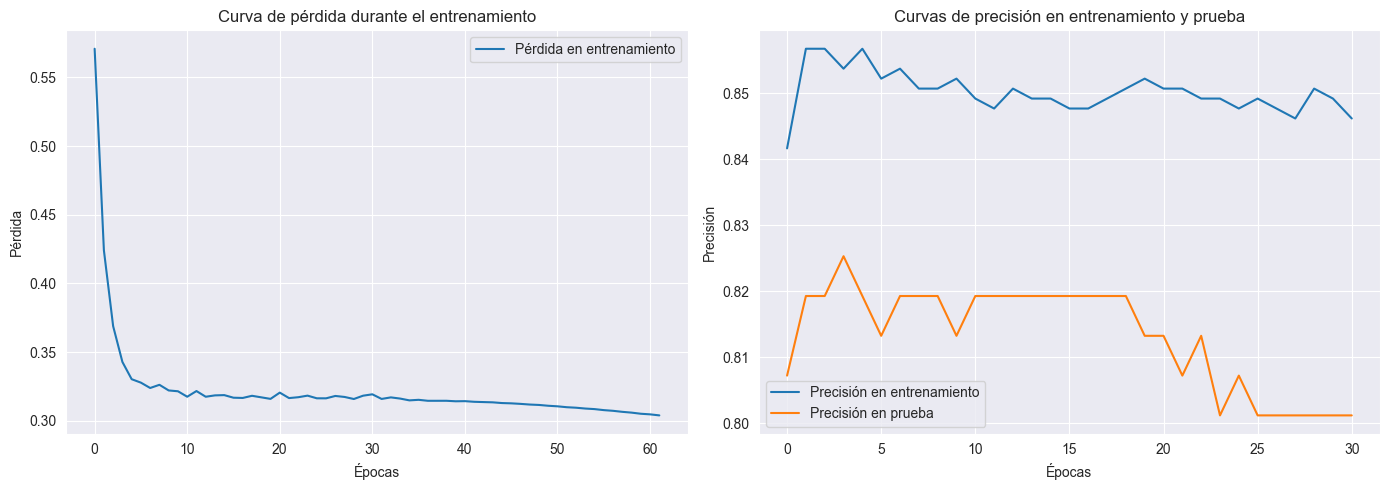

Train Accuracy: 0.8462
Test Accuracy: 0.8012


In [29]:
from src.data.data_transformer import convert_columns_values_to_numeric
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Cargar y preprocesar los datos
df = pd.read_csv('../data/raw/spotify_most_streamed_songs.csv', delimiter=",")
df = convert_columns_values_to_numeric(pd, df, df.select_dtypes(include='object').columns)
df = df.dropna(axis=1, how='all')
df = df.drop(['track_name', 'instrumentalness_%'], axis=1)
df = df.dropna(axis=0, how='any')

# Normalizar las columnas de entrada
df_stats = df.describe().T
df_norm = (df - df_stats['mean']) / df_stats['std']

# Seleccionar columnas de entrada y salida
X = df_norm[["in_spotify_playlists", "in_apple_playlists", "in_deezer_playlists"]].values
Y = (df["streams"].apply(lambda x: 1 if x > 100_000_000 else 0)).values

# División de los datos en entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Configurar la red neuronal con MLPClassifier
model = MLPClassifier(
    hidden_layer_sizes=(8,),     # Capa oculta con 4 neuronas
    activation='relu',           # Función de activación ReLU
    solver='adam',               # Optimizador Adam
    alpha=0.001,                  # Regularización L2 (lambda)
    learning_rate_init=0.1,     # Tasa de aprendizaje inicial
    max_iter=3000,               # Número máximo de épocas
    random_state=42,
    validation_fraction=0.2
)

# Entrenar el modelo
model.fit(X_train, Y_train)

# Guardar la curva de pérdida y calcular precisión por época
loss_values = model.loss_curve_

# Listas para almacenar la precisión en cada época
train_accuracies = []
test_accuracies = []

# Evaluar el modelo en cada época utilizando la función partial_fit
for i in range(1, len(loss_values) + 1):
    model.partial_fit(X_train, Y_train, classes=[0, 1])  # Continuar ajustando en cada época
    
    # Calcular precisión en entrenamiento y prueba
    train_accuracy = accuracy_score(Y_train, model.predict(X_train))
    test_accuracy = accuracy_score(Y_test, model.predict(X_test))
    
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Graficar la pérdida y precisión
plt.figure(figsize=(14, 5))

# Gráfico de Pérdida
plt.subplot(1, 2, 1)
plt.plot(loss_values, label='Pérdida en entrenamiento')
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida durante el entrenamiento")
plt.legend()

# Gráfico de Precisión
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Precisión en entrenamiento')
plt.plot(test_accuracies, label='Precisión en prueba')
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.title("Curvas de precisión en entrenamiento y prueba")
plt.legend()

plt.tight_layout()
plt.show()

# Precisión final
print(f"Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Test Accuracy: {test_accuracies[-1]:.4f}")
